# Proyek Klasifikasi Gambar: Intel Image Classification
- **Nama:** Vincent Oei
- **Email:** oei.vincent20@gmail.com
- **ID Dicoding:** vincent_oei_9nyw


## Import Semua Packages/Library yang Digunakan

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Patch protobuf runtime version check: tensorflowjs depends on a newer protobuf
# than TensorFlow 2.19 allows. Skipping the runtime check lets TFJS load safely.
import google.protobuf.runtime_version

def _validate_protobuf_version(*args, **kwargs):
    pass

google.protobuf.runtime_version.ValidateProtobufRuntimeVersion = _validate_protobuf_version

import json
import shutil
import gc
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
from sklearn.model_selection import train_test_split
import kagglehub

print("TensorFlow version:", tf.__version__)
print("KaggleHub version:", kagglehub.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))
print("Running on CPU with float32 precision.")

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)


2026-08-28 18:57:07.798565: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787918227.826388   24357 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787918227.835991   24357 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787918227.885635   24357 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787918227.885672   24357 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787918227.885673   24357 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
KaggleHub version: 1.0.2
GPU available: []
Running on CPU with float32 precision.


2026-08-28 18:57:10.508910: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## Data Preparation

### Data Loading

In [2]:
# Hyperparameters and paths
DATASET_NAME = "puneet6060/intel-image-classification"
IMG_SIZE = (160, 160)
BATCH_SIZE = 16
EPOCHS_TOP = 50
LEARNING_RATE_TOP = 1e-3
SEED = 42

# Download dataset from Kaggle (uses cache if available)
dataset_path = kagglehub.dataset_download(DATASET_NAME)
print("Dataset path:", dataset_path)

raw_train_dir = os.path.join(dataset_path, "seg_train", "seg_train")
print("Raw train directory:", raw_train_dir)
print("Classes found:", sorted([d for d in os.listdir(raw_train_dir) if os.path.isdir(os.path.join(raw_train_dir, d))]))


Dataset path: /home/vincentoei/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2
Raw train directory: /home/vincentoei/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train/seg_train
Classes found: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


### Data Preprocessing

#### Split Dataset

In [3]:
from collections import Counter

# Gather all image paths and labels from the source train folder
all_paths = []
all_labels = []
class_dirs = sorted([d for d in os.listdir(raw_train_dir) if os.path.isdir(os.path.join(raw_train_dir, d))])

for cls in class_dirs:
    cls_path = os.path.join(raw_train_dir, cls)
    files = [
        os.path.join(cls_path, f)
        for f in os.listdir(cls_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]
    all_paths.extend(files)
    all_labels.extend([cls] * len(files))

print(f"Total images in source train folder: {len(all_paths)}")
print(f"Classes: {class_dirs}")

# Manual stratified split: 80% train, 10% validation, 10% test
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, train_size=0.80, stratify=all_labels, random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=SEED
)

print(f"Train: {len(train_paths)} | Validation: {len(val_paths)} | Test: {len(test_paths)}")

# Copy files into a local split_data directory so image_dataset_from_directory
# can load the three splits directly.
split_base = "split_data"
if os.path.exists(split_base):
    shutil.rmtree(split_base)

for split_name, paths, labels in [
    ("train", train_paths, train_labels),
    ("val", val_paths, val_labels),
    ("test", test_paths, test_labels),
]:
    for path, label in zip(paths, labels):
        dest_dir = os.path.join(split_base, split_name, label)
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy2(path, dest_dir)

print("Dataset copied to split_data/")


Total images in source train folder: 14034
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train: 11227 | Validation: 1403 | Test: 1404


Dataset copied to split_data/


In [4]:
train_dir = os.path.join(split_base, "train")
val_dir = os.path.join(split_base, "val")
test_dir = os.path.join(split_base, "test")

# Load datasets. image_dataset_from_directory resizes mixed-resolution images on the fly.
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    label_mode="categorical",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    label_mode="categorical",
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="categorical",
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)
print("Num classes:", NUM_CLASSES)

with open("class_names.json", "w") as f:
    json.dump(class_names, f)
print("Saved class_names.json")


Found 11227 files belonging to 6 classes.


Found 1403 files belonging to 6 classes.


Found 1404 files belonging to 6 classes.


Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Num classes: 6
Saved class_names.json


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


In [6]:
# MobileNetV2 expects inputs scaled to [-1, 1].
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

# Light augmentation for training only.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

def apply_preprocessing(image, label):
    return preprocess(image), label

def apply_augment(image, label):
    return data_augmentation(image, training=True), label

train_ds = train_ds.map(apply_augment, num_parallel_calls=AUTOTUNE).map(apply_preprocessing, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = val_ds.map(apply_preprocessing, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds = test_ds.map(apply_preprocessing, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("Applied MobileNetV2 preprocessing and augmentation to datasets.")


Applied MobileNetV2 preprocessing and augmentation to datasets.


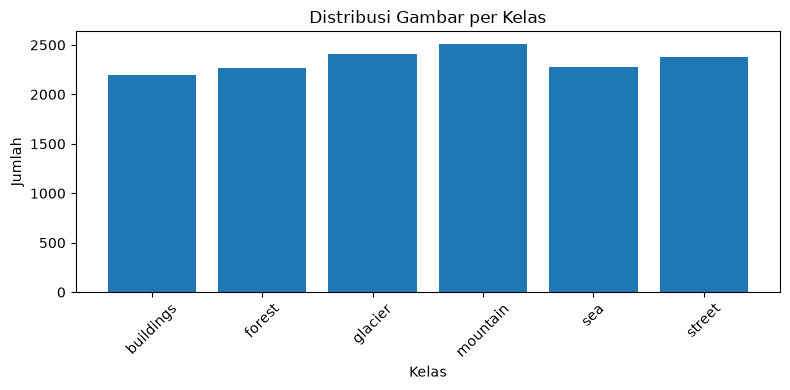

{'buildings': 2191, 'forest': 2271, 'glacier': 2404, 'mountain': 2512, 'sea': 2274, 'street': 2382}


In [7]:
label_counts = Counter(all_labels)

plt.figure(figsize=(8, 4))
plt.bar(label_counts.keys(), label_counts.values())
plt.title("Distribusi Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()
print(dict(label_counts))


## Modelling

Model menggunakan arsitektur **Sequential** dengan layer **Conv2D** dan **MaxPooling2D** eksplisit di atas basis *transfer learning* MobileNetV2 yang dibekukan. Fitur diekstrak sekali dari basis, kemudian bagian atas (*top*) dilatih terpisah untuk kecepatan di CPU.

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

def extract_features(dataset, base):
    '''Return (features, labels) numpy arrays without keeping all batches in a list.'''
    total = sum(labels.shape[0] for _, labels in dataset)
    for _, labels in dataset.take(1):
        pass
    for images, _ in dataset.take(1):
        feat = base(images, training=False)
        feat_shape = feat.shape[1:]
    features = np.empty((total, *feat_shape), dtype=np.float32)
    labels_arr = np.empty((total, NUM_CLASSES), dtype=np.float32)
    idx = 0
    for images, labels in dataset:
        feat = base(images, training=False).numpy()
        batch_size = labels.shape[0]
        features[idx:idx + batch_size] = feat
        labels_arr[idx:idx + batch_size] = labels.numpy()
        idx += batch_size
    return features, labels_arr

print("Extracting features from frozen MobileNetV2...")
train_features, train_labels = extract_features(train_ds, base_model)
val_features, val_labels = extract_features(val_ds, base_model)
test_features, test_labels = extract_features(test_ds, base_model)

print("Train features:", train_features.shape, train_labels.shape)
print("Val features:  ", val_features.shape, val_labels.shape)
print("Test features: ", test_features.shape, test_labels.shape)

# Release transient memory and cool down before top-model training.
gc.collect()
time.sleep(3)



Extracting features from frozen MobileNetV2...


Train features: (11227, 5, 5, 1280) (11227, 6)
Val features:   (1403, 5, 5, 1280) (1403, 6)
Test features:  (1404, 5, 5, 1280) (1404, 6)


In [9]:
feature_train_ds = (
    tf.data.Dataset.from_tensor_slices((train_features, train_labels))
    .shuffle(1000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
feature_val_ds = (
    tf.data.Dataset.from_tensor_slices((val_features, val_labels))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
feature_test_ds = (
    tf.data.Dataset.from_tensor_slices((test_features, test_labels))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


In [10]:
feature_shape = train_features.shape[1:]
print("Feature shape:", feature_shape)

# Define top layers as separate objects so they can be reused in the full model.
conv_layer = layers.Conv2D(
    256, (3, 3), activation="relu", padding="same",
    kernel_regularizer=regularizers.l2(1e-4), name="conv_top"
)
pool_layer = layers.MaxPooling2D((2, 2), name="pool_top")
gap_layer = layers.GlobalAveragePooling2D(name="gap_top")
bn_layer = layers.BatchNormalization(name="bn_top")
dense1 = layers.Dense(
    256, activation="relu",
    kernel_regularizer=regularizers.l2(1e-4), name="dense1_top"
)
dropout = layers.Dropout(0.5, name="dropout_top")
dense2 = layers.Dense(
    NUM_CLASSES, activation="softmax", dtype="float32", name="predictions"
)

top_model = models.Sequential([
    layers.InputLayer(input_shape=feature_shape, name="top_input"),
    conv_layer,
    pool_layer,
    gap_layer,
    bn_layer,
    dense1,
    dropout,
    dense2,
], name="classification_top")

top_model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE_TOP),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

top_model.summary()


Feature shape: (5, 5, 1280)


/home/vincentoei/projects/image-classification/venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "classification_top"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_top (Conv2D)               │ (None, 5, 5, 256)      │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_top (MaxPooling2D)         │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap_top                         │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_top (BatchNormalization)     │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1_top (Dense)              │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_top (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,017,734 (11.51 MB)

 Trainable params: 3,017,222 (11.51 MB)

 Non-trainable params: 512 (2.00 KB)

In [11]:
checkpoint_cb = callbacks.ModelCheckpoint(
    "best_top_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

early_stop_cb = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

lr_reduce_cb = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1,
)

callbacks_list = [checkpoint_cb, early_stop_cb, lr_reduce_cb]


In [12]:
history = top_model.fit(
    feature_train_ds,
    validation_data=feature_val_ds,
    epochs=EPOCHS_TOP,
    callbacks=callbacks_list,
)


Epoch 1/50


/home/vincentoei/projects/image-classification/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(



  1/702 ━━━━━━━━━━━━━━━━━━━━ 20:51 2s/step - accuracy: 0.0625 - loss: 2.8657


  4/702 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3750 - loss: 2.0056


  7/702 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.4911 - loss: 1.6434

...


701/702 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9976 - loss: 0.1094


Epoch 20: val_accuracy did not improve from 0.91518



702/702 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.9976 - loss: 0.1094 - val_accuracy: 0.9109 - val_loss: 0.6386 - learning_rate: 6.2500e-05


Epoch 20: early stopping


Restoring model weights from the end of the best epoch: 10.


### Membangun Model Sequential Lengkap

Layer yang sudah dilatih pada bagian atas digunakan kembali untuk membangun model lengkap yang menerima gambar mentah 160x160 sebagai input.

In [13]:
full_model = models.Sequential([
    layers.InputLayer(input_shape=IMG_SIZE + (3,)),
    base_model,
    conv_layer,
    pool_layer,
    gap_layer,
    bn_layer,
    dense1,
    dropout,
    dense2,
], name="intel_image_classifier")

full_model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE_TOP),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

full_model.summary()


Model: "intel_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_top (Conv2D)               │ (None, 5, 5, 256)      │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_top (MaxPooling2D)         │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap_top                         │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_top (BatchNormalization)     │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1_top (Dense)              │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_top (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,275,718 (20.13 MB)

 Trainable params: 3,017,222 (11.51 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

## Evaluasi dan Visualisasi

In [14]:
print("Evaluating full model on train/val/test sets...")
train_loss, train_acc = full_model.evaluate(train_ds, verbose=0)
val_loss, val_acc = full_model.evaluate(val_ds, verbose=0)
test_loss, test_acc = full_model.evaluate(test_ds, verbose=0)

print(f"Train accuracy:      {train_acc:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Test accuracy:       {test_acc:.4f}")

if train_acc < 0.90 or test_acc < 0.90:
    print("Target 90% accuracy not yet reached; fine-tuning will be attempted.")
else:
    print("Target 90% accuracy reached.")

# Cool down before the optional fine-tuning step.
gc.collect()
time.sleep(3)


Evaluating full model on train/val/test sets...


Train accuracy:      0.9276
Validation accuracy: 0.9152
Test accuracy:       0.9024
Target 90% accuracy reached.


## Fine Tuning

Unfreeze the last 20 layers of MobileNetV2 and fine-tune the full model at a low learning rate to push test accuracy above 85%.

In [15]:
# Save a snapshot before fine-tuning in case WSL crashes.
full_model.save("full_model_before_finetune.keras")

# Unfreeze only the top 20 layers of the pre-trained base.
base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Recompile with a very low learning rate.
full_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

finetune_checkpoint_cb = callbacks.ModelCheckpoint(
    "best_finetuned_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

finetune_early_stop_cb = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True,
    verbose=1,
)

finetune_lr_reduce_cb = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1,
)

print("Fine-tuning full model on CPU (last 20 MobileNetV2 layers)...")
finetune_history = full_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[finetune_checkpoint_cb, finetune_early_stop_cb, finetune_lr_reduce_cb],
)

# Re-evaluate after fine-tuning.
print("\nEvaluating fine-tuned full model...")
train_loss, train_acc = full_model.evaluate(train_ds, verbose=0)
val_loss, val_acc = full_model.evaluate(val_ds, verbose=0)
test_loss, test_acc = full_model.evaluate(test_ds, verbose=0)

print(f"Train accuracy:      {train_acc:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Test accuracy:       {test_acc:.4f}")

# Clean up memory before export.
gc.collect()
tf.keras.backend.clear_session()


Fine-tuning full model on CPU (last 20 MobileNetV2 layers)...
Epoch 1/30



  1/702 ━━━━━━━━━━━━━━━━━━━━ 30:45 3s/step - accuracy: 1.0000 - loss: 0.2133


  2/702 ━━━━━━━━━━━━━━━━━━━━ 1:12 103ms/step - accuracy: 0.9688 - loss: 0.4194


  3/702 ━━━━━━━━━━━━━━━━━━━━ 1:08 98ms/step - accuracy: 0.9375 - loss: 0.5013 


  4/702 ━━━━━━━━━━━━━━━━━━━━ 1:06 96ms/step - accuracy: 0.9219 - loss: 0.4995

...


702/702 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.9074 - loss: 0.4271 - val_accuracy: 0.9145 - val_loss: 0.4770 - learning_rate: 1.0000e-05


Epoch 14: early stopping


Restoring model weights from the end of the best epoch: 6.



Evaluating fine-tuned full model...


Train accuracy:      0.9305
Validation accuracy: 0.9145
Test accuracy:       0.9067


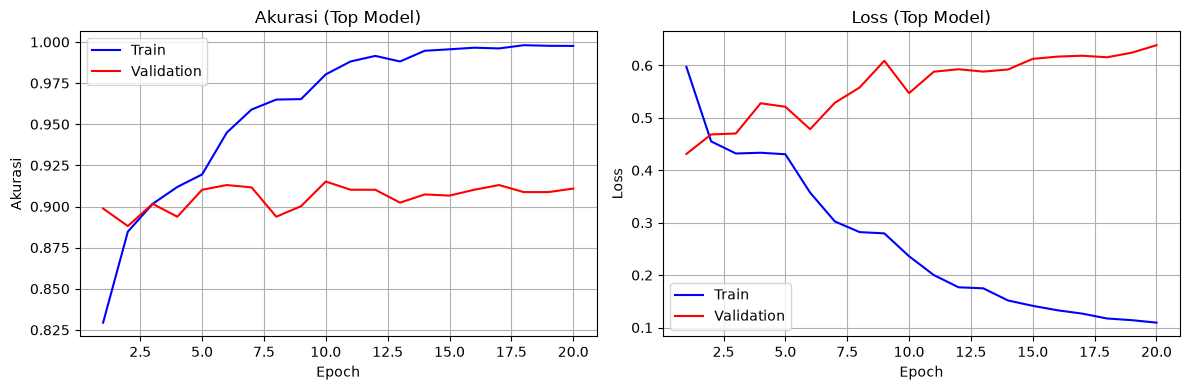

In [16]:
def plot_history(history, title_suffix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, "b-", label="Train")
    plt.plot(epochs, val_acc, "r-", label="Validation")
    plt.title(f"Akurasi {title_suffix}")
    plt.xlabel("Epoch")
    plt.ylabel("Akurasi")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, "b-", label="Train")
    plt.plot(epochs, val_loss, "r-", label="Validation")
    plt.title(f"Loss {title_suffix}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("training_history.png")
    plt.show()

plot_history(history, "(Top Model)")


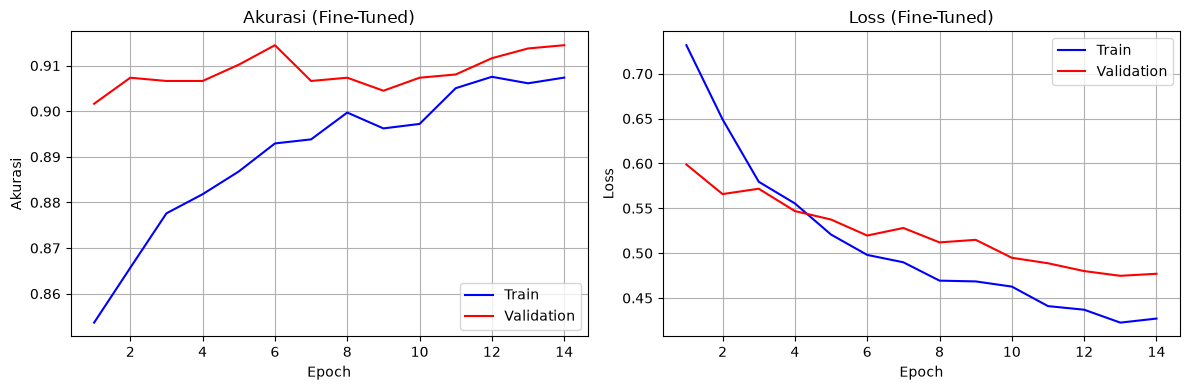

In [17]:
plot_history(finetune_history, "(Fine-Tuned)")


## Konversi Model

Menyimpan model dalam tiga format:
- **SavedModel**: format standar TensorFlow.
- **TF-Lite**: format ringan untuk perangkat mobile/embedded.
- **TFJS**: format untuk menjalankan model di browser melalui TensorFlow.js.

In [18]:
shutil.rmtree("saved_model", ignore_errors=True)
full_model.export("saved_model")
print("SavedModel exported to ./saved_model")
print("SavedModel contents:", os.listdir("saved_model"))


INFO:tensorflow:Assets written to: saved_model/assets


INFO:tensorflow:Assets written to: saved_model/assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_166')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  138234737125968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138234737128080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138234737128272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138234737127504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138234737126736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138234737128464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138234737130384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138234737130576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138234737129424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138234737128848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138234737127696

SavedModel exported to ./saved_model
SavedModel contents: ['saved_model.pb', 'fingerprint.pb', 'assets', 'variables']


In [19]:
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
tflite_model = converter.convert()

os.makedirs("tflite", exist_ok=True)
with open("tflite/model.tflite", "wb") as f:
    f.write(tflite_model)

with open("tflite/label.txt", "w") as f:
    f.write("\n".join(class_names))

print("TF-Lite model exported to ./tflite/model.tflite")
print("Labels:", class_names)


W0000 00:00:1787919656.464660   24357 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1787919656.465789   24357 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1787919656.532987   24357 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


TF-Lite model exported to ./tflite/model.tflite
Labels: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [20]:
import tensorflowjs as tfjs

shutil.rmtree("tfjs_model", ignore_errors=True)
os.makedirs("tfjs_model", exist_ok=True)
tfjs.converters.save_keras_model(full_model, "tfjs_model")

print("TFJS model exported to ./tfjs_model")
print("TFJS contents:", os.listdir("tfjs_model"))


failed to lookup keras version from the file,
    this is likely a weight only file
TFJS model exported to ./tfjs_model
TFJS contents: ['group1-shard2of6.bin', 'group1-shard3of6.bin', 'group1-shard6of6.bin', 'group1-shard4of6.bin', 'group1-shard5of6.bin', 'model.json', 'group1-shard1of6.bin']


## Inference (Optional)

Memuat kembali model TF-Lite dan menjalankan prediksi pada beberapa gambar dari test set sebagai bukti inferensi.

/home/vincentoei/projects/image-classification/venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


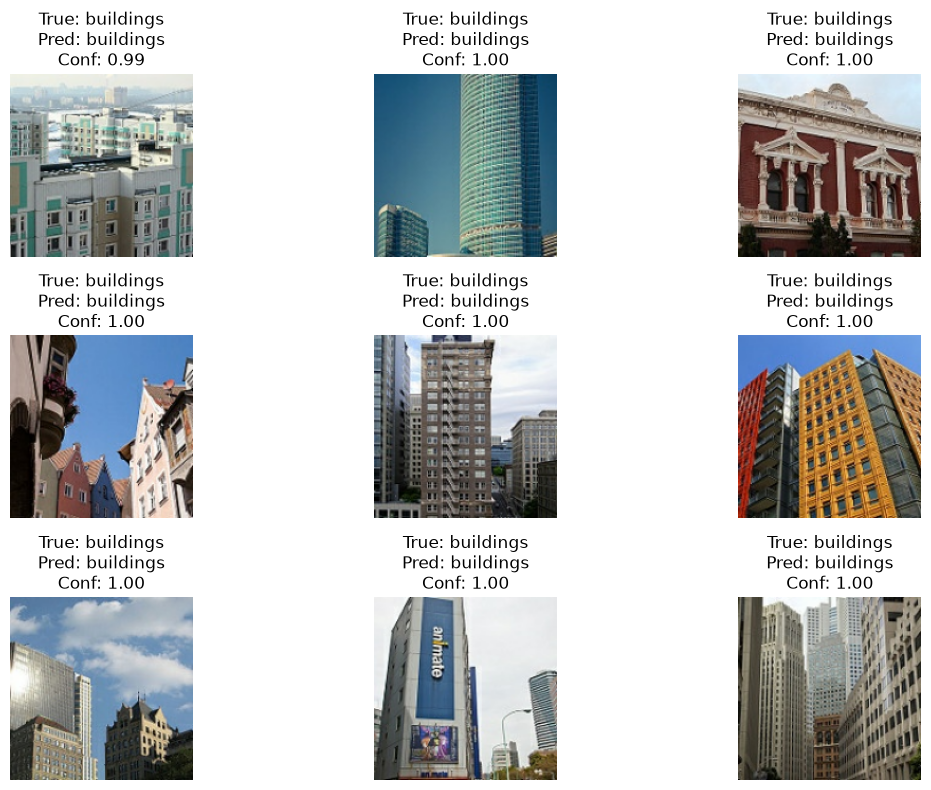

In [21]:
interpreter = tf.lite.Interpreter(model_path="tflite/model.tflite")
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

sample_images, sample_labels = next(iter(test_ds.take(1)))
batch_size = int(sample_images.shape[0])
interpreter.resize_tensor_input(input_details[0]["index"], [batch_size, *IMG_SIZE, 3])
interpreter.allocate_tensors()

input_data = tf.cast(sample_images, input_details[0]["dtype"]).numpy()

interpreter.set_tensor(input_details[0]["index"], input_data)
interpreter.invoke()
preds = interpreter.get_tensor(output_details[0]["index"])

pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(sample_labels.numpy(), axis=1)

# Reverse MobileNetV2 preprocessing so the images display correctly.
display_images = ((sample_images.numpy() + 1.0) * 127.5).clip(0, 255).astype("uint8")

plt.figure(figsize=(12, 8))
for i in range(min(9, len(sample_images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(display_images[i])
    plt.title(
        f"True: {class_names[true_classes[i]]}\n"
        f"Pred: {class_names[pred_classes[i]]}\n"
        f"Conf: {preds[i][pred_classes[i]]:.2f}"
    )
    plt.axis("off")
plt.tight_layout()
plt.savefig("inference_samples.png")
plt.show()
